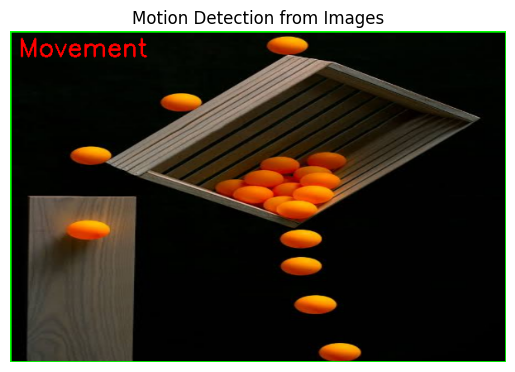

In [3]:
import cv2
import matplotlib.pyplot as plt

# Load two images instead of webcam
img1 = cv2.imread(r"C:\Users\marun\Downloads\i1.jpg")
img2 = cv2.imread(r"C:\Users\marun\Downloads\i2.jpg")

# Resize (important to match sizes)
img1 = cv2.resize(img1, (600, 400))
img2 = cv2.resize(img2, (600, 400))

# Difference
diff = cv2.absdiff(img1, img2)

# Gray
gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)

# Blur
blur = cv2.GaussianBlur(gray, (5,5), 0)

# Threshold
_, thresh = cv2.threshold(blur, 20, 255, cv2.THRESH_BINARY)

# Dilate
dilated = cv2.dilate(thresh, None, iterations=3)

# Contours
contours, _ = cv2.findContours(dilated, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Draw boxes on second image
for contour in contours:
    if cv2.contourArea(contour) < 1000:
        continue

    x, y, w, h = cv2.boundingRect(contour)

    cv2.rectangle(img2, (x, y), (x+w, y+h), (0,255,0), 2)
    cv2.putText(img2, "Movement", (10,30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 2)

# Show result
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Motion Detection from Images")
plt.show()